# Transformer Notebook


## Section 1: Why Attention Is Not Enough
Attention allows tokens to communicate.
We still need a mechanism to transform information.
We still need stable training.

## Section 2: Layer Normalization
Implement normalization manually

In [8]:
import torch
x = torch.tensor([
    [1.0, 2.0, 3.0],
    [5.0, 10.0, 15.0]
])

# Calculate - See pages 100 - 104
eps = 1e-5
mean = x.mean(dim=-1, keepdim=True) # Expect something ~0
variance = x.var(dim=-1, keepdim=True, unbiased=False) # Expect something ~1
normalized_output = (x - mean) / torch.sqrt(variance + eps)

In [9]:
# Verify with
print(normalized_output.mean(dim=-1))
print(normalized_output.var(dim=-1, unbiased=False))

tensor([0., 0.])
tensor([1.0000, 1.0000])


## Section 3: Exploring GELU
Compare ReLU and GELU

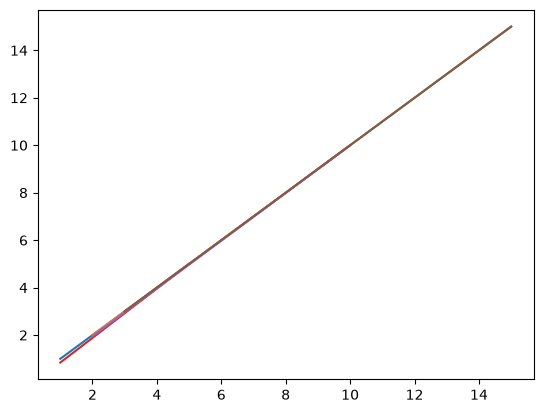

In [15]:
# Use this and plot both
import matplotlib.pyplot as plt

torch.linspace(-4, 4, 100)
relu_output = torch.relu(x)
gelu_output = 0.5*x*(1 + torch.tanh(torch.sqrt(torch.tensor(2.0 / torch.pi))*(x + 0.044715 * torch.pow(x,3))))

plt.plot(x, relu_output)
plt.plot(x, gelu_output)
plt.show()

## Section 4: Feed Forward Network
Review figure 4.10 in the book

In [18]:
# Create
input_shape = (2, 3, 768)
x = torch.rand(input_shape)

In [19]:
import torch.nn as nn

# Pass through 
#  Linear - Expect (2,3,768)
linear1 = nn.Linear(768, 3072)
#  GELU - Expect (2,3,3072)
gelu = nn.GELU()
#  Linear again - Expect (2,3,768) again
linear2 = nn.Linear(3072, 768)

hidden = linear1(x)
print(hidden.shape)

activated = gelu(hidden)
print(activated.shape)

output = linear2(activated)
print(output.shape)

torch.Size([2, 3, 3072])
torch.Size([2, 3, 3072])
torch.Size([2, 3, 768])


## Section 5: Residual Connections
Inspect output shapes using a toy network
Compare
 - With residual
 - Without residual

In [20]:

layer = nn.Sequential(nn.Linear(768, 768), nn.GELU())

x = torch.rand(2,3,768)

output_with_residual = x + layer(x)
output_without_residual = layer(x)

print(output_with_residual)
print(output_without_residual)

tensor([[[0.7269, 0.4001, 0.6616,  ..., 0.3361, 0.4677, 0.7272],
         [0.5697, 0.3732, 0.7322,  ..., 0.9373, 0.6400, 0.4322],
         [0.4189, 0.3282, 0.6964,  ..., 0.7490, 0.6489, 0.1865]],

        [[0.7672, 0.2675, 0.8797,  ..., 1.0311, 0.2224, 1.0114],
         [0.2562, 0.4532, 0.5881,  ..., 0.2124, 0.6544, 0.4612],
         [0.6521, 0.5781, 0.6130,  ..., 0.6606, 0.5688, 0.3782]]],
       grad_fn=<AddBackward0>)
tensor([[[ 0.0974,  0.0448, -0.0799,  ...,  0.2780,  0.2274, -0.0476],
         [-0.0768, -0.0828, -0.0811,  ...,  0.3048,  0.3457, -0.0885],
         [-0.0595, -0.0529, -0.0528,  ...,  0.2519,  0.1757, -0.1056]],

        [[-0.0962, -0.0291,  0.0587,  ...,  0.2147,  0.1665,  0.0115],
         [-0.0777, -0.1179, -0.0432,  ...,  0.2074,  0.1364, -0.1330],
         [ 0.0306,  0.0039, -0.0962,  ...,  0.2282,  0.1186, -0.0657]]],
       grad_fn=<GeluBackward0>)


## Section 6: Connecting Everything
This notebook has walked you through the following process, which is the blueprint for a TransformerBlock
 - Input
 - LayerNorm
 - Attention
 - Add Residual
 - LayerNorm
 - FeedForward
 - Add Residual
 - Output